🚀 Earth Engine conectado com sucesso!
⏳ Processando imagens na nuvem...
⚠️ Sem dados utilizáveis para a Chuva de 2016.
✅ Ano 2016 calculado com sucesso.
⚠️ Sem dados utilizáveis para a Chuva de 2017.
✅ Ano 2017 calculado com sucesso.
⚠️ Sem dados utilizáveis para a Seca de 2018.
⚠️ Sem dados utilizáveis para a Chuva de 2018.
✅ Ano 2019 calculado com sucesso.
✅ Ano 2020 calculado com sucesso.
✅ Ano 2021 calculado com sucesso.
✅ Ano 2022 calculado com sucesso.
✅ Ano 2023 calculado com sucesso.
✅ Ano 2024 calculado com sucesso.
✅ Ano 2025 calculado com sucesso.

📊 Planilha 'ndvi_valores_finais_tcc.csv' exportada com sucesso!


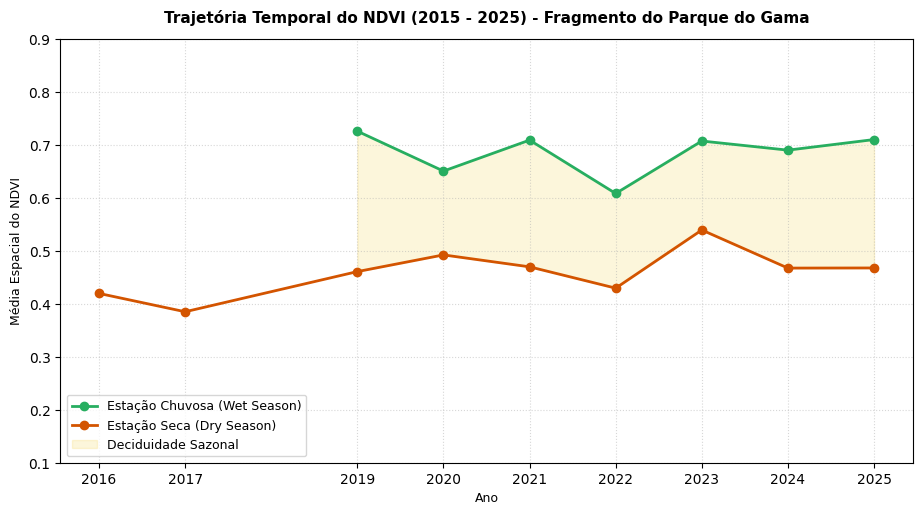

🖼️ Gráfico científico salvo como 'grafico_sazonalidade_ndvi_final.png'!


In [5]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. INICIALIZAÇÃO DO GOOGLE EARTH ENGINE
# ==========================================
try:
    ee.Initialize()
    print("🚀 Earth Engine conectado com sucesso!")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# ==========================================
# 2. ÁREA DE ESTUDO (Polígono do Parque do Gama)
# ==========================================
roi = ee.Geometry.Polygon([[
    [-48.065647754078306,-16.049668323693528],
    [-48.04837458487708,-16.049693087205977],
    [-48.043272393351984,-16.043297593813048],
    [-48.043213384753656,-16.04319448397201],
    [-48.043208020335626,-16.04311715155621],
    [-48.043267028933954,-16.04299857512701],
    [-48.043497698909235,-16.04264284541605],
    [-48.04402027450339,-16.0419245256787],
    [-48.044090011937776,-16.041772437596443],
    [-48.0471918990559,-16.03758536353105],
    [-48.047436345875084,-16.03730402947224],
    [-48.04780112630111,-16.03694828959639],
    [-48.048139084636986,-16.036703395834632],
    [-48.04848508959991,-16.03648943577546],
    [-48.04886020078586,-16.036327963601888],
    [-48.04945296897815,-16.036139781520852],
    [-48.05005378379749,-16.036062446367538],
    [-48.05054999246524,-16.036072757723044],
    [-48.05167115583347,-16.03635374195532],
    [-48.0523792590134,-16.036696593738935],
    [-48.05339313402103,-16.03722762616456],
    [-48.05398590221332,-16.037598832456922],
    [-48.05440969123767,-16.037918481765825],
    [-48.054670330408825,-16.038133591426664],
    [-48.05472129238011,-16.03822639264275],
    [-48.05490368259312,-16.038479017956533],
    [-48.05499755990864,-16.038695553684903],
    [-48.05509948385121,-16.0388167104779],
    [-48.05547499311329,-16.039208536197798],
    [-48.05581295144917,-16.039572005420307],
    [-48.05629038465382,-16.04026027511062],
    [-48.05668466937901,-16.04079469090439],
    [-48.05689778327941,-16.041101212264937],
    [-48.05698361396789,-16.041217212050963],
    [-48.05708017349242,-16.04131258960221],
    [-48.05735644102096,-16.04170698818083],
    [-48.05760588645934,-16.041956151675024],
    [-48.05787410736083,-16.042146906024517],
    [-48.0581745147705,-16.042293838304346],
    [-48.058517837524406,-16.042391793097373],
    [-48.0598990631103,-16.042474281306784],
    [-48.059279584884635,-16.04250005886523],
    [-48.05971410274505,-16.042469125794703],
    [-48.06018380092097,-16.042381482068805],
    [-48.060720242723946,-16.042185572424447],
    [-48.06133178637934,-16.04184015231916],
    [-48.06172137456375,-16.041572064660553],
    [-48.06197618442017,-16.041309132183514],
    [-48.06221758323151,-16.04105908823156],
    [-48.06250189738709,-16.040852866179417],
    [-48.062880088858186,-16.040633755015175],
    [-48.063384344152986,-16.04028059886693],
    [-48.065647754078306,-16.049668323693528]
]])

# ==========================================
# 3. FUNÇÕES DE PROCESSAMENTO RASTER
# ==========================================
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    # Divide por 10000 para corrigir a escala de reflectância de superfície (0 a 1)
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

def calculate_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

# ==========================================
# 4. TRATAMENTO E DICIONÁRIO DE DATAS ESTREITAS
# ==========================================
datas_seca = {
    2016: '2016-08-11', 2017: '2017-09-25', 2018: '2018-09-05', 2019: '2019-09-15', 2020: '2020-09-29',
    2021: '2021-08-25', 2022: '2022-08-30', 2023: '2023-08-05',
    2024: '2024-09-03', 2025: '2025-09-15'
}

datas_chuva = {
    2016: '2016-11-09', 2017: '2017-11-14', 2018: '2018-11-29',
    2019: '2019-12-29', 2020: '2020-11-08', 2021: '2021-01-27',
    2022: '2022-11-13', 2023: '2023-12-13', 2024: '2024-12-07',
    2025: '2025-03-07'
}

data_records = []
years_all = sorted(list(set(list(datas_seca.keys()) + list(datas_chuva.keys()))))

print("⏳ Processando imagens na nuvem...")

for year in years_all:
    date_dry = datas_seca.get(year)
    date_rain = datas_chuva.get(year)
    
    mean_dry = None
    mean_rain = None
    
    # Processamento da imagem exata da Seca
    if date_dry:
        try:
            img_dry = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                       .filterBounds(roi)
                       .filterDate(date_dry, ee.Date(date_dry).advance(2, 'day'))
                       .map(mask_s2_clouds)
                       .map(calculate_ndvi)
                       .first()
                       .clip(roi))
            stats_dry = img_dry.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_dry = stats_dry.get('NDVI')
        except Exception as e:
            print(f"⚠️ Sem dados utilizáveis para a Seca de {year}.")

    # Processamento da imagem exata da Chuva
    if date_rain:
        try:
            img_rain = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                        .filterBounds(roi)
                        .filterDate(date_rain, ee.Date(date_rain).advance(2, 'day'))
                        .map(mask_s2_clouds)
                        .map(calculate_ndvi)
                        .first()
                        .clip(roi))
            stats_rain = img_rain.select('NDVI').reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10).getInfo()
            mean_rain = stats_rain.get('NDVI')
        except Exception as e:
            print(f"⚠️ Sem dados utilizáveis para a Chuva de {year}.")
            
    # Armazena se houver pelo menos um dado na linha temporal
    if mean_dry is not None or mean_rain is not None:
        data_records.append({
            'Year': year,
            'NDVI_Rainy': mean_rain if mean_rain is not None else np.nan,
            'NDVI_Dry': mean_dry if mean_dry is not None else np.nan,
            'NDVI_Drop': (mean_rain - mean_dry) if (mean_rain is not None and mean_dry is not None) else np.nan,
            'Date_Rainy': date_rain if date_rain else 'Sem Informação',
            'Date_Dry': date_dry if date_dry else 'Sem Informação'
        })
        print(f"✅ Ano {year} calculado com sucesso.")

# ==========================================
# 5. SALVAR DADOS E EXPORTAR PLANILHA
# ==========================================
df_tcc = pd.DataFrame(data_records)
df_tcc.to_csv("ndvi_valores_finais_tcc.csv", index=False)
print("\n📊 Planilha 'ndvi_valores_finais_tcc.csv' exportada com sucesso!")

# ==========================================
# 6. MONTAGEM DO GRÁFICO HISTÓRICO
# ==========================================
plt.figure(figsize=(11, 5.5))

# Garante linhas contínuas limpando falhas pontuais no plot visual
df_rain_plot = df_tcc.dropna(subset=['NDVI_Rainy'])
df_dry_plot = df_tcc.dropna(subset=['NDVI_Dry'])

plt.plot(df_rain_plot['Year'], df_rain_plot['NDVI_Rainy'], marker='o', color='#27ae60', linewidth=2, label='Estação Chuvosa (Wet Season)')
plt.plot(df_dry_plot['Year'], df_dry_plot['NDVI_Dry'], marker='o', color='#d35400', linewidth=2, label='Estação Seca (Dry Season)')

# Preenchimento visual da lacuna de deciduidade (onde há o par de dados concomitantes)
df_gap = df_tcc.dropna(subset=['NDVI_Rainy', 'NDVI_Dry'])
plt.fill_between(df_gap['Year'], df_gap['NDVI_Rainy'], df_gap['NDVI_Dry'], color='#f1c40f', alpha=0.15, label='Deciduidade Sazonal')

plt.title('Trajetória Temporal do NDVI (2015 - 2025) - Fragmento do Parque do Gama', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Ano', fontsize=9)
plt.ylabel('Média Espacial do NDVI', fontsize=9)
plt.xticks(df_tcc['Year'])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', fontsize=9)
plt.ylim(0.1, 0.9)

plt.savefig("grafico_sazonalidade_ndvi_final.png", dpi=300, bbox_inches='tight')
plt.show()
print("🖼️ Gráfico científico salvo como 'grafico_sazonalidade_ndvi_final.png'!")